In [ ]:
!pip install -q \
    pandas \
    numpy \
    scikit-learn \
    matplotlib \
    seaborn \
    transformers \
    datasets \
    sentence-transformers \
    hdbscan \
    umap-learn \
    shap \
    lime \
    plotly \
    python-dotenv \
    openai \
    joblib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import os
import re
import json
import random
import warnings
import zipfile
import shutil

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

warnings.filterwarnings("ignore")

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
PROJECT_DIR = "/content/ADEGuard-GenAI"

folders = [
    "data/raw",
    "data/processed",
    "data/combined",
    "models/ner",
    "models/severity",
    "models/embeddings",
    "results",
    "reports"
]

for folder in folders:
    os.makedirs(
        os.path.join(PROJECT_DIR, folder),
        exist_ok=True
    )

print("Project created at:")
print(PROJECT_DIR)

Project created at:
/content/ADEGuard-GenAI


In [ ]:
import os

uploaded_files = os.listdir("/content")

for file in sorted(uploaded_files):
    if file.endswith(".csv"):
        print(file)

2024VAERSDATA.csv
2024VAERSSYMPTOMS.csv
2024VAERSVAX.csv
2025VAERSDATA.csv
2025VAERSSYMPTOMS.csv
2025VAERSVAX.csv
2026VAERSDATA.csv
2026VAERSSYMPTOMS.csv
2026VAERSVAX.csv


In [ ]:
for year in ["2024", "2025", "2026"]:

    files = [
        f"{year}VAERSDATA.csv",
        f"{year}VAERSSYMPTOMS.csv",
        f"{year}VAERSVAX.csv"
    ]

    for file in files:

        source = f"/content/{file}"
        destination = f"{PROJECT_DIR}/data/raw/{file}"

        if os.path.exists(source):
            shutil.move(source, destination)
            print("Moved:", file)
        else:
            print("NOT FOUND:", file)

Moved: 2024VAERSDATA.csv
Moved: 2024VAERSSYMPTOMS.csv
Moved: 2024VAERSVAX.csv
Moved: 2025VAERSDATA.csv
Moved: 2025VAERSSYMPTOMS.csv
Moved: 2025VAERSVAX.csv
Moved: 2026VAERSDATA.csv
Moved: 2026VAERSSYMPTOMS.csv
Moved: 2026VAERSVAX.csv


In [ ]:
raw_dir = f"{PROJECT_DIR}/data/raw"

print("Files in raw data folder:\n")

for file in sorted(os.listdir(raw_dir)):
    print(file)

Files in raw data folder:

2024VAERSDATA.csv
2024VAERSSYMPTOMS.csv
2024VAERSVAX.csv
2025VAERSDATA.csv
2025VAERSSYMPTOMS.csv
2025VAERSVAX.csv
2026VAERSDATA.csv
2026VAERSSYMPTOMS.csv
2026VAERSVAX.csv


In [ ]:
years = [2024, 2025, 2026]

dataframes = []

for year in years:

    path = f"{PROJECT_DIR}/data/raw/{year}VAERSDATA.csv"

    df_year = pd.read_csv(
        path,
        encoding="latin1",
        low_memory=False
    )

    df_year["DATA_YEAR"] = year

    dataframes.append(df_year)

    print(
        f"{year}:",
        df_year.shape
    )

vaers_data = pd.concat(
    dataframes,
    ignore_index=True
)

print("\nCombined dataset:")
print(vaers_data.shape)

2024: (52889, 37)
2025: (40804, 37)
2026: (15516, 37)

Combined dataset:
(109209, 37)


In [ ]:
symptom_dfs = []

for year in years:

    path = f"{PROJECT_DIR}/data/raw/{year}VAERSSYMPTOMS.csv"

    df_year = pd.read_csv(
        path,
        encoding="latin1",
        low_memory=False
    )

    df_year["DATA_YEAR"] = year

    symptom_dfs.append(df_year)

    print(
        f"{year} symptoms:",
        df_year.shape
    )

vaers_symptoms = pd.concat(
    symptom_dfs,
    ignore_index=True
)

print("\nCombined symptoms:")
print(vaers_symptoms.shape)

2024 symptoms: (65335, 13)
2025 symptoms: (49042, 13)
2026 symptoms: (18420, 13)

Combined symptoms:
(132797, 13)


In [ ]:
vaccine_dfs = []

for year in years:

    path = f"{PROJECT_DIR}/data/raw/{year}VAERSVAX.csv"

    df_year = pd.read_csv(
        path,
        encoding="latin1",
        low_memory=False
    )

    df_year["DATA_YEAR"] = year

    vaccine_dfs.append(df_year)

    print(
        f"{year} vaccine:",
        df_year.shape
    )

vaers_vaccine = pd.concat(
    vaccine_dfs,
    ignore_index=True
)

print("\nCombined vaccine data:")
print(vaers_vaccine.shape)

2024 vaccine: (68649, 10)
2025 vaccine: (54116, 10)
2026 vaccine: (21067, 10)

Combined vaccine data:
(143832, 10)


In [ ]:
print("VAERS main reports:", vaers_data.shape)
print("VAERS symptoms:", vaers_symptoms.shape)
print("VAERS vaccines:", vaers_vaccine.shape)

VAERS main reports: (109209, 37)
VAERS symptoms: (132797, 13)
VAERS vaccines: (143832, 10)


In [ ]:
vaers_data.head()

,VAERS_ID,RECVDATE,STATE,AGE_YRS,CAGE_YR,CAGE_MO,SEX,RPT_DATE,SYMPTOM_TEXT,DIED,...,PRIOR_VAX,SPLTTYPE,FORM_VERS,TODAYS_DATE,BIRTH_DEFECT,OFC_VISIT,ER_ED_VISIT,ALLERGIES,ORDER,DATA_YEAR
0,2728969,01/01/2024,AK,14.0,NaN,NaN,M,NaN,fluzone qiv hd administered to a minor patient...,NaN,...,NaN,USSA2023SA396019,2,12/30/2023,NaN,NaN,NaN,NaN,1,2024
1,2728982,01/01/2024,NJ,NaN,NaN,NaN,U,NaN,administering vaccines subcutaneously to patie...,NaN,...,NaN,USGSKUS2023AMR179885,2,01/01/2024,NaN,NaN,NaN,NaN,1,2024
2,2728984,01/01/2024,NaN,NaN,NaN,NaN,U,NaN,extreme joint pain; Unable to walk; This non-s...,NaN,...,NaN,USGSKUS2023AMR180978,2,01/01/2024,NaN,NaN,NaN,NaN,1,2024
3,2728992,01/01/2024,MO,NaN,NaN,NaN,F,NaN,was due to have 2nd when everything shut down ...,NaN,...,NaN,USGSKUS2023AMR181463,2,01/01/2024,NaN,NaN,NaN,NaN,1,2024
4,2728993,01/01/2024,NaN,NaN,NaN,NaN,U,NaN,Injection site hot; Hypersentivity reaction; C...,NaN,...,NaN,USGSKUS2023AMR181703,2,01/01/2024,NaN,NaN,NaN,NaN,1,2024


In [ ]:
print(vaers_data.columns.tolist())

['VAERS_ID', 'RECVDATE', 'STATE', 'AGE_YRS', 'CAGE_YR', 'CAGE_MO', 'SEX', 'RPT_DATE', 'SYMPTOM_TEXT', 'DIED', 'DATEDIED', 'L_THREAT', 'ER_VISIT', 'HOSPITAL', 'HOSPDAYS', 'X_STAY', 'DISABLE', 'RECOVD', 'VAX_DATE', 'ONSET_DATE', 'NUMDAYS', 'LAB_DATA', 'V_ADMINBY', 'V_FUNDBY', 'OTHER_MEDS', 'CUR_ILL', 'HISTORY', 'PRIOR_VAX', 'SPLTTYPE', 'FORM_VERS', 'TODAYS_DATE', 'BIRTH_DEFECT', 'OFC_VISIT', 'ER_ED_VISIT', 'ALLERGIES', 'ORDER', 'DATA_YEAR']


In [ ]:
vaers_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109209 entries, 0 to 109208
Data columns (total 37 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   VAERS_ID      109209 non-null  int64  
 1   RECVDATE      109209 non-null  object 
 2   STATE         92101 non-null   object 
 3   AGE_YRS       85221 non-null   float64
 4   CAGE_YR       78528 non-null   float64
 5   CAGE_MO       9393 non-null    float64
 6   SEX           102471 non-null  object 
 7   RPT_DATE      220 non-null     object 
 8   SYMPTOM_TEXT  108740 non-null  object 
 9   DIED          1658 non-null    object 
 10  DATEDIED      1194 non-null    object 
 11  L_THREAT      1665 non-null    object 
 12  ER_VISIT      64 non-null      object 
 13  HOSPITAL      5351 non-null    object 
 14  HOSPDAYS      3273 non-null    float64
 15  X_STAY        62 non-null      object 
 16  DISABLE       3226 non-null    object 
 17  RECOVD        96277 non-null   object 
 18  VAX_

In [ ]:
medical_keywords = [
    "SYMPTOM",
    "NARRATIVE",
    "HISTORY",
    "ALLERG",
    "RECOV",
    "DIED",
    "HOSPITAL",
    "DISABLE",
    "LIFE",
    "ER",
    "VAX",
    "AGE",
    "SEX"
]

important_columns = []

for column in vaers_data.columns:

    column_upper = column.upper()

    if any(
        keyword in column_upper
        for keyword in medical_keywords
    ):
        important_columns.append(column)

print("Potentially useful columns:\n")

for column in important_columns:
    print(column)

Potentially useful columns:

VAERS_ID
AGE_YRS
CAGE_YR
CAGE_MO
SEX
SYMPTOM_TEXT
DIED
DATEDIED
ER_VISIT
HOSPITAL
DISABLE
RECOVD
VAX_DATE
OTHER_MEDS
HISTORY
PRIOR_VAX
FORM_VERS
ER_ED_VISIT
ALLERGIES
ORDER


In [ ]:
severity_columns = [
    column
    for column in vaers_data.columns
    if any(
        keyword in column.upper()
        for keyword in [
            "DIED",
            "HOSPITAL",
            "DISABLE",
            "LIFE",
            "ER"
        ]
    )
]

print("Severity-related columns:")
print(severity_columns)

Severity-related columns:
['VAERS_ID', 'DIED', 'DATEDIED', 'ER_VISIT', 'HOSPITAL', 'DISABLE', 'OTHER_MEDS', 'FORM_VERS', 'ER_ED_VISIT', 'ALLERGIES', 'ORDER']


In [ ]:
for column in severity_columns:

    print("\n" + "=" * 60)
    print(column)

    print(
        vaers_data[column]
        .value_counts(dropna=False)
        .head(10)
    )


VAERS_ID
VAERS_ID
2822006    5
2763490    5
2742312    5
2870850    4
2776126    4
2867321    4
2749835    4
2791591    4
2873922    3
2789503    3
Name: count, dtype: int64

DIED
DIED
NaN    107551
Y        1658
Name: count, dtype: int64

DATEDIED
DATEDIED
NaN           108015
11/02/2023         6
11/03/2023         6
01/01/2024         6
01/25/2024         5
12/13/2023         5
10/20/2024         5
11/09/2023         5
03/14/2025         5
01/18/2024         5
Name: count, dtype: int64

ER_VISIT
ER_VISIT
NaN    109145
Y          64
Name: count, dtype: int64

HOSPITAL
HOSPITAL
NaN    103858
Y        5351
Name: count, dtype: int64

DISABLE
DISABLE
NaN    105983
Y        3226
Name: count, dtype: int64

OTHER_MEDS
OTHER_MEDS
NaN                69806
none                3728
unknown             1214
NONE                 878
Unknown              813
No                   378
UNKNOWN              335
Sterile diluent      333
no                   321
None.                220
Name: count, dt

In [ ]:
missing = pd.DataFrame({
    "column": vaers_data.columns,
    "missing_count": vaers_data.isna().sum(),
    "missing_percentage":
        vaers_data.isna().mean() * 100
})

missing = missing.sort_values(
    "missing_percentage",
    ascending=False
)

missing.head(30)

,column,missing_count,missing_percentage
X_STAY,X_STAY,109147,99.943228
ER_VISIT,ER_VISIT,109145,99.941397
BIRTH_DEFECT,BIRTH_DEFECT,109134,99.931324
RPT_DATE,RPT_DATE,108989,99.798551
V_FUNDBY,V_FUNDBY,108977,99.787563
DATEDIED,DATEDIED,108015,98.906684
DIED,DIED,107551,98.481810
L_THREAT,L_THREAT,107544,98.475400
DISABLE,DISABLE,105983,97.046031
HOSPDAYS,HOSPDAYS,105936,97.002994


DATA_YEAR
2024    52889
2025    40804
2026    15516
Name: count, dtype: int64


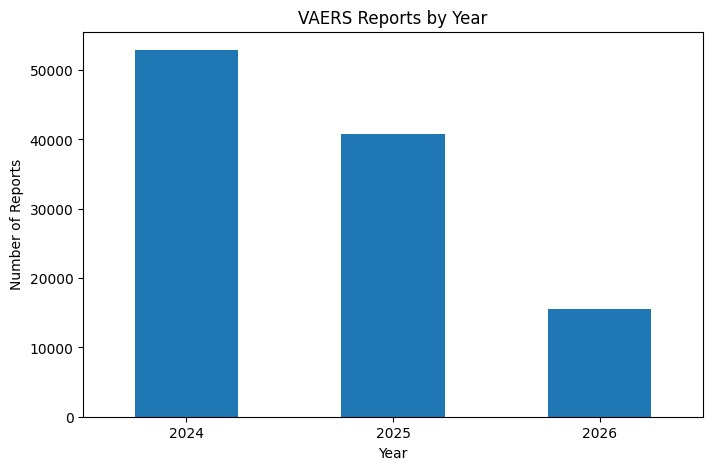

In [ ]:
year_counts = (
    vaers_data["DATA_YEAR"]
    .value_counts()
    .sort_index()
)

print(year_counts)

plt.figure(figsize=(8, 5))

year_counts.plot(kind="bar")

plt.title("VAERS Reports by Year")
plt.xlabel("Year")
plt.ylabel("Number of Reports")
plt.xticks(rotation=0)

plt.show()

In [ ]:
combined_path = (
    f"{PROJECT_DIR}/data/combined/"
    "vaers_2024_2026_main.csv"
)

vaers_data.to_csv(
    combined_path,
    index=False
)

print("Saved:")
print(combined_path)

Saved:
/content/ADEGuard-GenAI/data/combined/vaers_2024_2026_main.csv


In [ ]:
symptoms_path = (
    f"{PROJECT_DIR}/data/combined/"
    "vaers_2024_2026_symptoms.csv"
)

vaers_symptoms.to_csv(
    symptoms_path,
    index=False
)

print("Saved:")
print(symptoms_path)

Saved:
/content/ADEGuard-GenAI/data/combined/vaers_2024_2026_symptoms.csv


In [ ]:
vaccine_path = (
    f"{PROJECT_DIR}/data/combined/"
    "vaers_2024_2026_vaccines.csv"
)

vaers_vaccine.to_csv(
    vaccine_path,
    index=False
)

print("Saved:")
print(vaccine_path)

Saved:
/content/ADEGuard-GenAI/data/combined/vaers_2024_2026_vaccines.csv


In [ ]:
for i, column in enumerate(vaers_data.columns):
    print(f"{i:3} | {column:40} | {vaers_data[column].dtype}")

  0 | VAERS_ID                                 | int64
  1 | RECVDATE                                 | object
  2 | STATE                                    | object
  3 | AGE_YRS                                  | float64
  4 | CAGE_YR                                  | float64
  5 | CAGE_MO                                  | float64
  6 | SEX                                      | object
  7 | RPT_DATE                                 | object
  8 | SYMPTOM_TEXT                             | object
  9 | DIED                                     | object
 10 | DATEDIED                                 | object
 11 | L_THREAT                                 | object
 12 | ER_VISIT                                 | object
 13 | HOSPITAL                                 | object
 14 | HOSPDAYS                                 | float64
 15 | X_STAY                                   | object
 16 | DISABLE                                  | object
 17 | RECOVD                                 

In [ ]:
outcome_columns = [
    "DIED",
    "DATEDIED",
    "L_THREAT",
    "ER_VISIT",
    "ER_ED_VISIT",
    "HOSPITAL",
    "HOSPDAYS",
    "X_STAY",
    "DISABLE",
    "RECOVD"
]

existing_outcomes = [
    col for col in outcome_columns
    if col in vaers_data.columns
]

print("Available outcome columns:")
print(existing_outcomes)

Available outcome columns:
['DIED', 'DATEDIED', 'L_THREAT', 'ER_VISIT', 'ER_ED_VISIT', 'HOSPITAL', 'HOSPDAYS', 'X_STAY', 'DISABLE', 'RECOVD']


In [ ]:
def normalize_yes_no(value):
    if pd.isna(value):
        return "N"

    value = str(value).strip().upper()

    if value == "Y":
        return "Y"

    return "N"


for column in existing_outcomes:
    vaers_data[column] = vaers_data[column].apply(
        normalize_yes_no
    )

print("Outcome fields normalized.")

Outcome fields normalized.


In [ ]:
for column in existing_outcomes:
    print("\n", column)
    print(
        vaers_data[column]
        .value_counts()
    )


 DIED
DIED
N    107551
Y      1658
Name: count, dtype: int64

 DATEDIED
DATEDIED
N    109209
Name: count, dtype: int64

 L_THREAT
L_THREAT
N    107544
Y      1665
Name: count, dtype: int64

 ER_VISIT
ER_VISIT
N    109145
Y        64
Name: count, dtype: int64

 ER_ED_VISIT
ER_ED_VISIT
N    99583
Y     9626
Name: count, dtype: int64

 HOSPITAL
HOSPITAL
N    103858
Y      5351
Name: count, dtype: int64

 HOSPDAYS
HOSPDAYS
N    109209
Name: count, dtype: int64

 X_STAY
X_STAY
N    109147
Y        62
Name: count, dtype: int64

 DISABLE
DISABLE
N    105983
Y      3226
Name: count, dtype: int64

 RECOVD
RECOVD
N    80244
Y    28965
Name: count, dtype: int64


In [ ]:
def determine_severity(row):

    if (
        row.get("DIED", "N") == "Y"
        or row.get("L_THREAT", "N") == "Y"
        or row.get("DISABLE", "N") == "Y"
        or row.get("HOSPITAL", "N") == "Y"
    ):
        return "severe"

    if (
        row.get("ER_VISIT", "N") == "Y"
        or row.get("ER_ED_VISIT", "N") == "Y"
    ):
        return "moderate"

    return "mild"


vaers_data["severity"] = vaers_data.apply(
    determine_severity,
    axis=1
)

print(
    vaers_data["severity"]
    .value_counts()
)

severity
mild        93341
severe       9240
moderate     6628
Name: count, dtype: int64


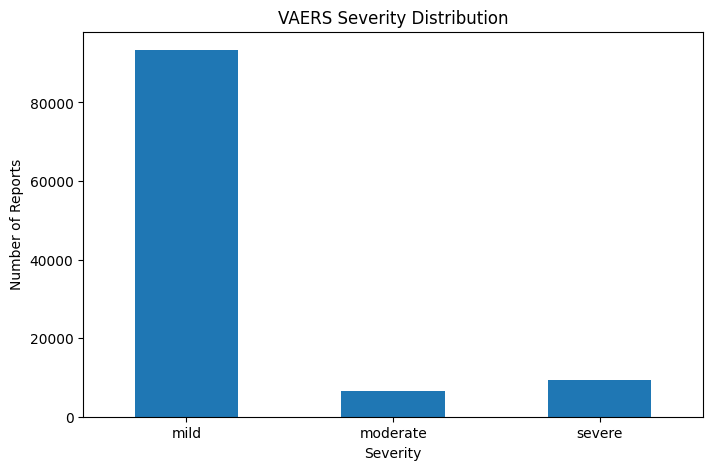

In [ ]:
severity_counts = (
    vaers_data["severity"]
    .value_counts()
    .reindex(["mild", "moderate", "severe"])
)

plt.figure(figsize=(8, 5))

severity_counts.plot(kind="bar")

plt.title("VAERS Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Number of Reports")
plt.xticks(rotation=0)

plt.show()

In [ ]:
severity_summary = pd.DataFrame({
    "count": severity_counts,
    "percentage": (
        severity_counts /
        severity_counts.sum() * 100
    )
})

severity_summary

,count,percentage
severity,,
mild,93341,85.470062
moderate,6628,6.069097
severe,9240,8.460841


In [ ]:
year_severity = pd.crosstab(
    vaers_data["DATA_YEAR"],
    vaers_data["severity"]
)

year_severity

severity,mild,moderate,severe
DATA_YEAR,,,
2024,45256,2979,4654
2025,34796,2629,3379
2026,13289,1020,1207


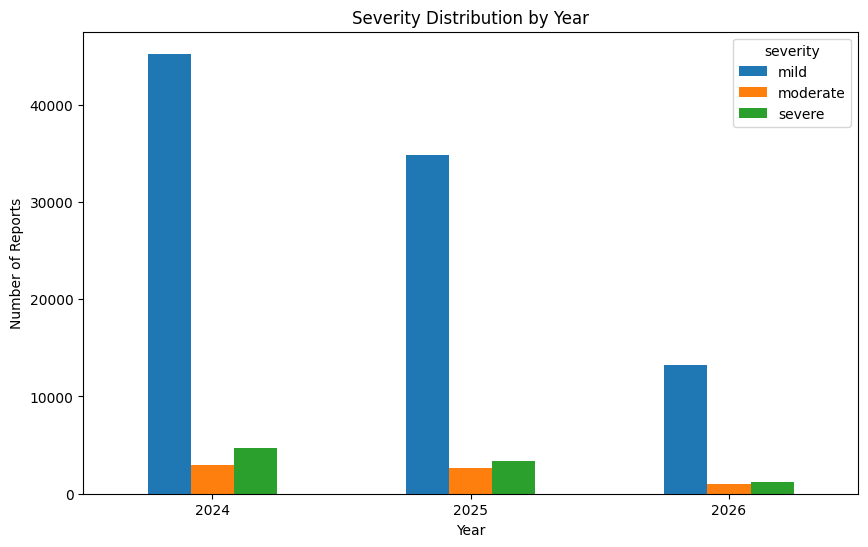

In [ ]:
year_severity.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Severity Distribution by Year")
plt.xlabel("Year")
plt.ylabel("Number of Reports")
plt.xticks(rotation=0)

plt.show()

In [ ]:
text_candidates = [
    column
    for column in vaers_data.columns
    if any(
        keyword in column.upper()
        for keyword in [
            "NARRATIVE",
            "HISTORY",
            "SYMPTOM"
        ]
    )
]

print("Text-related columns:")
print(text_candidates)

Text-related columns:
['SYMPTOM_TEXT', 'HISTORY']


In [ ]:
possible_text_columns = [
    "SYMPTOM_TEXT",
    "HISTORY",
    "CUR_ILL",
    "OTHER_MEDS",
    "ALLERGIES"
]

text_columns = [
    col
    for col in possible_text_columns
    if col in vaers_data.columns
]

print("Text columns being used:")
print(text_columns)

Text columns being used:
['SYMPTOM_TEXT', 'HISTORY', 'CUR_ILL', 'OTHER_MEDS', 'ALLERGIES']


In [ ]:
def combine_text(row):

    parts = []

    for column in text_columns:

        value = row[column]

        if pd.notna(value):

            value = str(value).strip()

            if value:
                parts.append(value)

    return " ".join(parts)


vaers_data["medical_text"] = vaers_data.apply(
    combine_text,
    axis=1
)

print(
    vaers_data[
        ["medical_text", "severity"]
    ].head()
)

                                        medical_text severity
0  fluzone qiv hd administered to a minor patient...     mild
1  administering vaccines subcutaneously to patie...     mild
2  extreme joint pain; Unable to walk; This non-s...     mild
3  was due to have 2nd when everything shut down ...     mild
4  Injection site hot; Hypersentivity reaction; C...     mild


In [ ]:
def clean_medical_text(text):

    if pd.isna(text):
        return ""

    text = str(text)
    text = re.sub(r"\s+", " ", text)
    text = text.strip()

    return text


vaers_data["medical_text"] = (
    vaers_data["medical_text"]
    .apply(clean_medical_text)
)

print("Text preprocessing completed.")

Text preprocessing completed.


In [ ]:
before = len(vaers_data)

vaers_data = vaers_data[
    vaers_data["medical_text"].str.len() > 20
].copy()

after = len(vaers_data)

print("Records before:", before)
print("Records after:", after)
print("Removed:", before - after)

Records before: 109209
Records after: 108130
Removed: 1079


In [ ]:
before = len(vaers_data)

vaers_data = (
    vaers_data
    .drop_duplicates(subset=["VAERS_ID"])
    .copy()
)

after = len(vaers_data)

print("Before:", before)
print("After:", after)
print("Duplicates removed:", before - after)

Before: 108130
After: 106583
Duplicates removed: 1547


In [ ]:
print(
    vaers_data["severity"]
    .value_counts()
)

print("\nPercentages:")

print(
    vaers_data["severity"]
    .value_counts(normalize=True) * 100
)

severity
mild        91223
severe       8886
moderate     6474
Name: count, dtype: int64

Percentages:
severity
mild        85.588696
severe       8.337164
moderate     6.074139
Name: proportion, dtype: float64


In [ ]:
pd.set_option(
    "display.max_colwidth",
    500
)

vaers_data[
    ["VAERS_ID", "medical_text", "severity"]
].sample(
    min(10, len(vaers_data)),
    random_state=42
)

,VAERS_ID,medical_text,severity
33765,2789893,"Flareup of Bullous Pemphigoid starting one week after vaccination. Multiple blisters on arms, legs, torso, and hands. CHF, Bullous Pemphigoid Xarelto? Allopurinal, Entresto",mild
9715,2748993,"Admitted to hospital 1/24, discharged 1/25: Her first seizure involved drooling, R arm jerking, head turning to the left, and L eye deviation and bilateral eyes rolling backward; lasted for 5 minutes. Her second seizure involved bilateral upper and lower extremity shaking and bilateral eyes rolling backward; lasted for 10 minutes. Mom called 911 and movements stopped when EMS arrived. She was febrile to 102F in ambulance. She had third seizure at facility with similar semiology to previous a...",severe
37294,2794560,"Site: Bruising at Injection Site-Severe, Site: Pain at Injection Site-Severe, Site: Swelling at Injection Site-Severe",mild
47499,2809261,"pt states that about after 3 days her right arm became really red, hot, and swollen around the injection site the size of a plum. She ice it down. After about 5 days she became nauseated and is hurting in the stomach area. She has lost her appetite. The injection site is no longer red but still has a knot that is painful and has an annoying itch that seems to come and go. The pain is getting some better but she has been advised by pharmacy to see her provider since it has been a week and she...",mild
37406,2794725,"hard boiled egg inflammation at the site of the 1st vaccine; hard boiled egg inflammation at the site of the 1st vaccine/swelling at injection site; hard boiled egg inflammation at the site of the 1st vaccine; flu like symptoms; This non-serious case was reported by a consumer via call center representative and described the occurrence of injection site inflammation in a female patient who received Herpes zoster (Shingrix) for prophylaxis. On an unknown date, the patient received the 1st dos...",mild
33364,2789257,"Systemic: Incontinence-Medium, Other Vaccines: VaccineTypeBrand: Comirnaty 2024-2025; Manufacturer: Pfizer; LotNumber: LM2222; Route: IM; BodySite: Arm; Dose: 1; VaxDate: 08/30/2024",mild
25789,2775683,"Patient received HPV vaccine on 6/13/24, and a pink rash occurred at the injection site 3 days later. On 6/20/24, the rash at the injection site turned purple and is painful. Patient has tried ibuprofen and benadryl to help with reaction, but no improvement. Patient plans to see a provider on 6/26/24 if no improvement.",mild
75532,2855333,Itchy rash at the injection site on left upper arm/shoulder area.,mild
15869,2759317,"No additional AEs; patient received improperly stored vaccine; This spontaneous report was received from a Medical Assistant and refers to a patient of unknown age and gender. The patient's medical history, concurrent conditions and concomitant therapies were not provided. On 26-MAR-2024, the patient was vaccinated with improperly stored vaccine: varicella virus vaccine live (oka/merck) (VARIVAX) injection, 1 dose, lot #X024543, expiration date: 10-OCT-2025, administered for prophylaxis (ana...",mild
17424,2762234,"No additional AE; patient was inadvertently administered a dose of PROQUAD that suffered a Temperature Excursion (TE); This spontaneous report was received from a nurse and refers to a patient of unknown age and gender. The patient's medical history and concurrent conditions were not provided. The concomitant medications included diluent. On 09-APR-2024, the patient was vaccinated with measles, mumps, rubella and varicella (oka-merck) virus vaccine live (PROQUAD) injection (recombinant Human...",mild


In [ ]:
ml_data = vaers_data[
    [
        "VAERS_ID",
        "DATA_YEAR",
        "medical_text",
        "severity"
    ]
].copy()

ml_data.head()

,VAERS_ID,DATA_YEAR,medical_text,severity
0,2728969,2024,fluzone qiv hd administered to a minor patient with no reported adverse event; patient was supposed to receive the Flumist Nasal Spray but she grabbed the FLUZONE QIV HD and inadvertently gave it to intranasally with no reported adverse event; patient was supposed to receive the Flumist Nasal Spray but she grabbed the FLUZONE QIV HD and inadvertently gave it to intranasally with no reported adverse event; Initial information received from Regulatory Authority on 18-Dec-2023 regarding an unso...,mild
1,2728982,2024,administering vaccines subcutaneously to patients; Reason for deletion: No GSK suspect,mild
2,2728984,2024,"extreme joint pain; Unable to walk; This non-serious case was reported by a consumer via interactive digital media and described the occurrence of joint pain in a patient who received RSVPreF3 adjuvanted (Arexvy) for prophylaxis. On an unknown date, the patient received Arexvy. On an unknown date, an unknown time after receiving Arexvy, the patient experienced joint pain (Verbatim: extreme joint pain) and unable to walk (Verbatim: Unable to walk). The outcome of the joint pain and unable to ...",mild
3,2728992,2024,"was due to have 2nd when everything shut down for pandemic; This non-serious case was reported by a consumer via call center representative and described the occurrence of social problem in a 54-year-old female patient who received Herpes zoster (Shingrix) for prophylaxis. Previously administered products included Shingrix (received 1st dose in 2019). On an unknown date, the patient did not receive the 2nd dose of Shingrix. On an unknown date, an unknown time after receiving Shingrix, the pa...",mild
4,2728993,2024,Injection site hot; Hypersentivity reaction; Chills/Shivering; cold and hot; temperature was 100.5; redness expanded and completely circled the entire am/Injection site redness; all around arm and very itchy/ itchy in the size for the golf ball; area of hardness was probably like the size of an orange or avocado; was a good sized lump/the lump in arm about the size of a golf ball now; Hives; This non-serious case was reported by a consumer via other manufacturer and described the occurrence ...,mild


In [ ]:
print("Final ML dataset shape:")
print(ml_data.shape)

Final ML dataset shape:
(106583, 4)


In [ ]:
processed_path = (
    f"{PROJECT_DIR}/data/processed/"
    "vaers_2024_2026_processed.csv"
)

ml_data.to_csv(
    processed_path,
    index=False
)

print("Processed dataset saved to:")
print(processed_path)

Processed dataset saved to:
/content/ADEGuard-GenAI/data/processed/vaers_2024_2026_processed.csv


In [ ]:
X = ml_data["medical_text"]
y = ml_data["severity"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining distribution:")
print(y_train.value_counts())

print("\nTesting distribution:")
print(y_test.value_counts())

Training samples: 85266
Testing samples: 21317

Training distribution:
severity
mild        72978
severe       7109
moderate     5179
Name: count, dtype: int64

Testing distribution:
severity
mild        18245
severe       1777
moderate     1295
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

ml_data["label"] = label_encoder.fit_transform(
    ml_data["severity"]
)

print("Label mapping:")

for label, number in zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
):
    print(f"{label} -> {number}")

Label mapping:
mild -> 0
moderate -> 1
severe -> 2


In [ ]:
from datasets import Dataset

train_df = ml_data.loc[
    X_train.index,
    ["medical_text", "label"]
].copy()

test_df = ml_data.loc[
    X_test.index,
    ["medical_text", "label"]
].copy()

train_dataset = Dataset.from_pandas(
    train_df,
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df,
    preserve_index=False
)

print(train_dataset)
print(test_dataset)

Dataset({
    features: ['medical_text', 'label'],
    num_rows: 85266
})
Dataset({
    features: ['medical_text', 'label'],
    num_rows: 21317
})


In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "dmis-lab/biobert-v1.1"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("Tokenizer loaded successfully!")

config.json:   0%|          | 0.00/462 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer loaded successfully!


In [ ]:
def tokenize_function(examples):

    return tokenizer(
        examples["medical_text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )


tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True
)

print(tokenized_train)

Map:   0%|          | 0/85266 [00:00<?, ? examples/s]

Map:   0%|          | 0/21317 [00:00<?, ? examples/s]

Dataset({
    features: ['medical_text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 85266
})


In [ ]:
from transformers import (
    AutoModelForSequenceClassification
)

num_labels = 3

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels
)

print("BioBERT classification model loaded!")

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  433MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  433MB            

[transformers] BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-v1.1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BioBERT classification model loaded!


model.safetensors: downloading bytes:           |  0.00B            

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model.to(device)

print("Model device:", device)

Model device: cuda


In [ ]:
if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

GPU: Tesla T4


In [ ]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    f1 = f1_score(
        labels,
        predictions,
        average="weighted"
    )

    return {
        "accuracy": accuracy,
        "f1": f1
    }

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir=f"{PROJECT_DIR}/models/severity",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=3,

    weight_decay=0.01,

    logging_steps=50,

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    greater_is_better=True,

    report_to="none",

    fp16=torch.cuda.is_available()
)

print("Training configuration created.")

Training configuration created.


In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=tokenized_train,

    eval_dataset=tokenized_test,

    processing_class=tokenizer,

    compute_metrics=compute_metrics
)

print("Trainer ready!")

Trainer ready!


In [ ]:
training_result = trainer.train()

print("Training completed!")

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.322016,0.244419,0.923582,0.918622
2,0.243520,0.270335,0.925787,0.922298
3,0.181491,0.346466,0.923535,0.920411


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training completed!


In [ ]:
evaluation_result = trainer.evaluate()

print("Evaluation results:")

for key, value in evaluation_result.items():
    print(f"{key}: {value}")

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.181491,0.270335,3,0.925787,0.922298


Evaluation results:
eval_loss: 0.2703348398208618
eval_accuracy: 0.9257869306187549
eval_f1: 0.9222977145959159


In [ ]:
predictions_output = trainer.predict(
    tokenized_test
)

predicted_labels = np.argmax(
    predictions_output.predictions,
    axis=1
)

true_labels = predictions_output.label_ids

In [ ]:
print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        mild       0.95      0.97      0.96     18245
    moderate       0.65      0.49      0.56      1295
      severe       0.80      0.75      0.77      1777

    accuracy                           0.93     21317
   macro avg       0.80      0.74      0.76     21317
weighted avg       0.92      0.93      0.92     21317



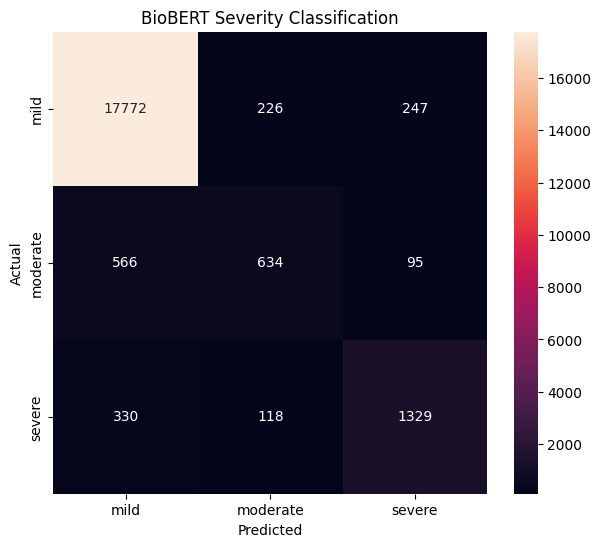

In [ ]:
cm = confusion_matrix(
    true_labels,
    predicted_labels
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BioBERT Severity Classification")

plt.show()

In [ ]:
severity_model_path = (
    f"{PROJECT_DIR}/models/severity/biobert"
)

trainer.save_model(
    severity_model_path
)

tokenizer.save_pretrained(
    severity_model_path
)

print("Severity model saved at:")
print(severity_model_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Severity model saved at:
/content/ADEGuard-GenAI/models/severity/biobert


In [ ]:
def predict_severity(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    model.eval()

    with torch.no_grad():

        outputs = model(**inputs)

        probabilities = torch.softmax(
            outputs.logits,
            dim=-1
        )

    predicted_id = torch.argmax(
        probabilities,
        dim=-1
    ).item()

    predicted_label = (
        label_encoder.inverse_transform(
            [predicted_id]
        )[0]
    )

    confidence = (
        probabilities[0][predicted_id]
        .item()
    )

    return predicted_label, confidence

In [ ]:
test_report = """
Patient developed difficulty breathing and
was admitted to the hospital after vaccination.
"""

prediction, confidence = predict_severity(
    test_report
)

print("Report:")
print(test_report)

print("\nPredicted severity:")
print(prediction.upper())

print(
    f"\nConfidence: {confidence:.2%}"
)

Report:

Patient developed difficulty breathing and
was admitted to the hospital after vaccination.


Predicted severity:
SEVERE

Confidence: 97.70%


In [ ]:
results = {
    "accuracy": accuracy_score(
        true_labels,
        predicted_labels
    ),

    "weighted_f1": f1_score(
        true_labels,
        predicted_labels,
        average="weighted"
    )
}

results_path = (
    f"{PROJECT_DIR}/results/"
    "severity_model_results.json"
)

with open(results_path, "w") as f:
    json.dump(results, f, indent=4)

print("Results saved:")
print(results_path)

Results saved:
/content/ADEGuard-GenAI/results/severity_model_results.json


In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    pipeline
)

NER_MODEL_NAME = "d4data/biomedical-ner-all"

ner_tokenizer = AutoTokenizer.from_pretrained(
    NER_MODEL_NAME
)

ner_model = AutoModelForTokenClassification.from_pretrained(
    NER_MODEL_NAME
)

print("Biomedical NER model loaded successfully!")

config.json:   0%|          | 0.00/5.00k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/373 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  266MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Biomedical NER model loaded successfully!


In [ ]:
ner_device = 0 if torch.cuda.is_available() else -1

ner_pipeline = pipeline(
    "ner",
    model=ner_model,
    tokenizer=ner_tokenizer,
    aggregation_strategy="simple",
    device=ner_device
)

print("NER pipeline ready!")

NER pipeline ready!


In [ ]:
sample_text = """
Patient developed severe headache, nausea,
and dizziness after receiving Pfizer vaccine.
"""

entities = ner_pipeline(sample_text)

for entity in entities:
    print(entity)

{'entity_group': 'Severity', 'score': np.float32(0.99982053), 'word': 'severe', 'start': 19, 'end': 25}
{'entity_group': 'Sign_symptom', 'score': np.float32(0.9978479), 'word': 'headache', 'start': 26, 'end': 34}
{'entity_group': 'Sign_symptom', 'score': np.float32(0.99991584), 'word': 'di', 'start': 48, 'end': 50}
{'entity_group': 'Sign_symptom', 'score': np.float32(0.99813133), 'word': '##zziness', 'start': 50, 'end': 57}
{'entity_group': 'Medication', 'score': np.float32(0.974207), 'word': 'pfizer', 'start': 74, 'end': 80}


In [ ]:
def extract_entities(text):

    entities = ner_pipeline(text)

    extracted = []

    for entity in entities:
        extracted.append({
            "text": entity["word"],
            "label": entity["entity_group"],
            "score": round(float(entity["score"]), 4),
            "start": entity["start"],
            "end": entity["end"]
        })

    return extracted


sample_entities = extract_entities(sample_text)

pd.DataFrame(sample_entities)

,text,label,score,start,end
0,severe,Severity,0.9998,19,25
1,headache,Sign_symptom,0.9978,26,34
2,di,Sign_symptom,0.9999,48,50
3,##zziness,Sign_symptom,0.9981,50,57
4,pfizer,Medication,0.9742,74,80


In [ ]:
id2label = ner_model.config.id2label

print("NER labels:\n")

for key, value in id2label.items():
    print(key, "→", value)

NER labels:

0 → O
1 → B-Activity
2 → B-Administration
3 → B-Age
4 → B-Area
5 → B-Biological_attribute
6 → B-Biological_structure
7 → B-Clinical_event
8 → B-Color
9 → B-Coreference
10 → B-Date
11 → B-Detailed_description
12 → B-Diagnostic_procedure
13 → B-Disease_disorder
14 → B-Distance
15 → B-Dosage
16 → B-Duration
17 → B-Family_history
18 → B-Frequency
19 → B-Height
20 → B-History
21 → B-Lab_value
22 → B-Mass
23 → B-Medication
24 → B-Non[biological](Detailed_description
25 → B-Nonbiological_location
26 → B-Occupation
27 → B-Other_entity
28 → B-Other_event
29 → B-Outcome
30 → B-Personal_[back](Biological_structure
31 → B-Personal_background
32 → B-Qualitative_concept
33 → B-Quantitative_concept
34 → B-Severity
35 → B-Sex
36 → B-Shape
37 → B-Sign_symptom
38 → B-Subject
39 → B-Texture
40 → B-Therapeutic_procedure
41 → B-Time
42 → B-Volume
43 → B-Weight
44 → I-Activity
45 → I-Administration
46 → I-Age
47 → I-Area
48 → I-Biological_attribute
49 → I-Biological_structure
50 → I-Clinical_ev

In [ ]:
ENTITY_MAPPING = {
    "CHEMICAL": "DRUG",
    "CHEMICAL_SUBSTANCE": "DRUG",
    "DRUG": "DRUG",
    "MEDICATION": "DRUG",

    "DISEASE": "DISEASE",
    "DISEASE_DISORDER": "DISEASE",
    "SIGN_SYMPTOM": "SYMPTOM",
    "SYMPTOM": "SYMPTOM",

    "DOSAGE": "DOSAGE",
    "ROUTE": "ROUTE",
    "FREQUENCY": "FREQUENCY",
    "DURATION": "DURATION",

    "SEVERITY": "SEVERITY"
}

print(ENTITY_MAPPING)

{'CHEMICAL': 'DRUG', 'CHEMICAL_SUBSTANCE': 'DRUG', 'DRUG': 'DRUG', 'MEDICATION': 'DRUG', 'DISEASE': 'DISEASE', 'DISEASE_DISORDER': 'DISEASE', 'SIGN_SYMPTOM': 'SYMPTOM', 'SYMPTOM': 'SYMPTOM', 'DOSAGE': 'DOSAGE', 'ROUTE': 'ROUTE', 'FREQUENCY': 'FREQUENCY', 'DURATION': 'DURATION', 'SEVERITY': 'SEVERITY'}


In [ ]:
def normalize_entity_label(label):

    label = str(label).upper().strip()

    return ENTITY_MAPPING.get(
        label,
        label
    )

In [ ]:
def extract_normalized_entities(text):

    entities = ner_pipeline(text)

    extracted = []

    for entity in entities:

        original_label = entity["entity_group"]

        normalized_label = normalize_entity_label(
            original_label
        )

        extracted.append({
            "text": entity["word"],
            "original_label": original_label,
            "label": normalized_label,
            "confidence": round(
                float(entity["score"]),
                4
            ),
            "start": entity["start"],
            "end": entity["end"]
        })

    return extracted

In [ ]:
test_text = """
Patient developed severe headache and nausea
after receiving Pfizer vaccine.
The patient also experienced dizziness
and vomiting.
"""

entities = extract_normalized_entities(
    test_text
)

pd.DataFrame(entities)

,text,original_label,label,confidence,start,end
0,severe,Severity,SEVERITY,0.9998,19,25
1,headache,Sign_symptom,SYMPTOM,0.9999,26,34
2,nausea,Sign_symptom,SYMPTOM,0.9999,39,45
3,pfizer,Medication,DRUG,0.9643,62,68
4,di,Sign_symptom,SYMPTOM,0.9999,107,109
5,##zziness,Sign_symptom,SYMPTOM,0.9998,109,116


In [ ]:
print(
    "Number of reports:",
    len(ml_data)
)

Number of reports: 106583


In [ ]:
NER_SAMPLE_SIZE = min(
    5000,
    len(ml_data)
)

ner_working_data = ml_data.sample(
    NER_SAMPLE_SIZE,
    random_state=42
).copy()

print(
    "Reports selected for NER:",
    len(ner_working_data)
)

Reports selected for NER: 5000


In [ ]:
from tqdm.auto import tqdm

tqdm.pandas()

ner_working_data["entities"] = (
    ner_working_data["medical_text"]
    .progress_apply(
        extract_normalized_entities
    )
)

print("NER processing completed!")

  0%|          | 0/5000 [00:00<?, ?it/s]

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


NER processing completed!


In [ ]:
ner_working_data[
    [
        "VAERS_ID",
        "medical_text",
        "entities"
    ]
].head()

,VAERS_ID,medical_text,entities
33765,2789893,"Flareup of Bullous Pemphigoid starting one week after vaccination. Multiple blisters on arms, legs, torso, and hands. CHF, Bullous Pemphigoid Xarelto? Allopurinal, Entresto","[{'text': 'flare', 'original_label': 'Sign_symptom', 'label': 'SYMPTOM', 'confidence': 0.7982, 'start': 0, 'end': 5}, {'text': 'bull', 'original_label': 'Detailed_description', 'label': 'DETAILED_DESCRIPTION', 'confidence': 0.9824, 'start': 11, 'end': 15}, {'text': '##ous', 'original_label': 'Disease_disorder', 'label': 'DISEASE', 'confidence': 0.4327, 'start': 15, 'end': 18}, {'text': 'pemphigoid', 'original_label': 'Disease_disorder', 'label': 'DISEASE', 'confidence': 0.9402, 'start': 19, ..."
9715,2748993,"Admitted to hospital 1/24, discharged 1/25: Her first seizure involved drooling, R arm jerking, head turning to the left, and L eye deviation and bilateral eyes rolling backward; lasted for 5 minutes. Her second seizure involved bilateral upper and lower extremity shaking and bilateral eyes rolling backward; lasted for 10 minutes. Mom called 911 and movements stopped when EMS arrived. She was febrile to 102F in ambulance. She had third seizure at facility with similar semiology to previous a...","[{'text': 'admitted', 'original_label': 'Clinical_event', 'label': 'CLINICAL_EVENT', 'confidence': 0.9998, 'start': 0, 'end': 8}, {'text': 'hospital', 'original_label': 'Nonbiological_location', 'label': 'NONBIOLOGICAL_LOCATION', 'confidence': 0.9992, 'start': 12, 'end': 20}, {'text': 'discharged', 'original_label': 'Clinical_event', 'label': 'CLINICAL_EVENT', 'confidence': 0.93, 'start': 27, 'end': 37}, {'text': 'seizure', 'original_label': 'Sign_symptom', 'label': 'SYMPTOM', 'confidence': ..."
37294,2794560,"Site: Bruising at Injection Site-Severe, Site: Pain at Injection Site-Severe, Site: Swelling at Injection Site-Severe","[{'text': 'br', 'original_label': 'Sign_symptom', 'label': 'SYMPTOM', 'confidence': 0.9999, 'start': 6, 'end': 8}, {'text': '##uising', 'original_label': 'Sign_symptom', 'label': 'SYMPTOM', 'confidence': 0.9996, 'start': 8, 'end': 14}, {'text': 'injection', 'original_label': 'Therapeutic_procedure', 'label': 'THERAPEUTIC_PROCEDURE', 'confidence': 0.9075, 'start': 18, 'end': 27}, {'text': 'severe', 'original_label': 'Severity', 'label': 'SEVERITY', 'confidence': 0.9996, 'start': 33, 'end': 39..."
47499,2809261,"pt states that about after 3 days her right arm became really red, hot, and swollen around the injection site the size of a plum. She ice it down. After about 5 days she became nauseated and is hurting in the stomach area. She has lost her appetite. The injection site is no longer red but still has a knot that is painful and has an annoying itch that seems to come and go. The pain is getting some better but she has been advised by pharmacy to see her provider since it has been a week and she...","[{'text': 'after 3 days', 'original_label': 'Date', 'label': 'DATE', 'confidence': 0.9972, 'start': 21, 'end': 33}, {'text': 'right arm', 'original_label': 'Biological_structure', 'label': 'BIOLOGICAL_STRUCTURE', 'confidence': 0.9999, 'start': 38, 'end': 47}, {'text': 'swollen', 'original_label': 'Sign_symptom', 'label': 'SYMPTOM', 'confidence': 0.9999, 'start': 76, 'end': 83}, {'text': 'injection site', 'original_label': 'Therapeutic_procedure', 'label': 'THERAPEUTIC_PROCEDURE', 'confidence..."
37406,2794725,"hard boiled egg inflammation at the site of the 1st vaccine; hard boiled egg inflammation at the site of the 1st vaccine/swelling at injection site; hard boiled egg inflammation at the site of the 1st vaccine; flu like symptoms; This non-serious case was reported by a consumer via call center representative and described the occurrence of injection site inflammation in a female patient who received Herpes zoster (Shingrix) for prophylaxis. On an unknown date, the patient received the 1st dos...","[{'text': 'hard', 'original_label': 'Detailed_description', 'label': 'DETAILED_DESCRIPTIO

In [ ]:
entity_records = []

for _, row in ner_working_data.iterrows():

    for entity in row["entities"]:

        entity_records.append({
            "VAERS_ID": row["VAERS_ID"],
            "severity": row["severity"],
            "entity_text": entity["text"],
            "entity_label": entity["label"],
            "confidence": entity["confidence"]
        })

entity_df = pd.DataFrame(
    entity_records
)

print(
    "Total extracted entities:",
    len(entity_df)
)

entity_df.head(20)

Total extracted entities: 104548


,VAERS_ID,severity,entity_text,entity_label,confidence
0,2789893,mild,flare,SYMPTOM,0.7982
1,2789893,mild,bull,DETAILED_DESCRIPTION,0.9824
2,2789893,mild,##ous,DISEASE,0.4327
3,2789893,mild,pemphigoid,DISEASE,0.9402
4,2789893,mild,one week,DATE,0.9885
5,2789893,mild,b,SYMPTOM,0.9999
6,2789893,mild,##listers,SYMPTOM,0.7268
7,2789893,mild,bull,DETAILED_DESCRIPTION,0.8299
8,2789893,mild,pemphigo,DISEASE,0.8195
9,2789893,mild,##tres,DETAILED_DESCRIPTION,0.7600


In [ ]:
entity_counts = (
    entity_df["entity_label"]
    .value_counts()
)

print(entity_counts)

entity_label
DRUG                      25359
SYMPTOM                   20539
DETAILED_DESCRIPTION       8060
DISEASE                    5691
BIOLOGICAL_STRUCTURE       5492
DATE                       5490
DIAGNOSTIC_PROCEDURE       4744
LAB_VALUE                  4697
DOSAGE                     3506
THERAPEUTIC_PROCEDURE      3022
NONBIOLOGICAL_LOCATION     2281
COREFERENCE                1726
TIME                       1564
CLINICAL_EVENT             1563
AGE                        1543
SEVERITY                   1337
ADMINISTRATION             1330
DURATION                   1289
SEX                        1274
HISTORY                    1261
SUBJECT                     998
ACTIVITY                    498
FREQUENCY                   323
FAMILY_HISTORY              153
OUTCOME                     138
COLOR                       138
DISTANCE                    112
QUANTITATIVE_CONCEPT        111
OTHER_ENTITY                 62
OTHER_EVENT                  54
OCCUPATION                 

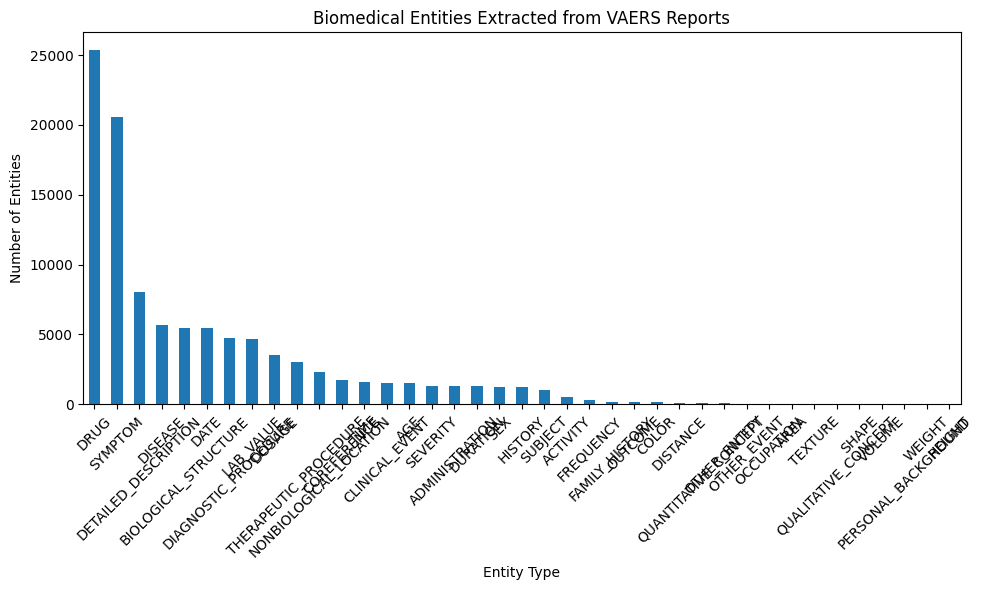

In [ ]:
plt.figure(figsize=(10, 6))

entity_counts.plot(
    kind="bar"
)

plt.title(
    "Biomedical Entities Extracted from VAERS Reports"
)

plt.xlabel("Entity Type")
plt.ylabel("Number of Entities")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [ ]:
symptom_entities = entity_df[
    entity_df["entity_label"].str.upper() == "SYMPTOM"
].copy()

print(
    "Number of symptom entities:",
    len(symptom_entities)
)

symptom_entities.head(20)

Number of symptom entities: 20539


,VAERS_ID,severity,entity_text,entity_label,confidence
0,2789893,mild,flare,SYMPTOM,0.7982
5,2789893,mild,b,SYMPTOM,0.9999
6,2789893,mild,##listers,SYMPTOM,0.7268
14,2748993,severe,seizure,SYMPTOM,0.9999
15,2748993,severe,dr,SYMPTOM,0.5281
19,2748993,severe,eye deviation,SYMPTOM,0.7368
21,2748993,severe,rolling,SYMPTOM,0.9969
23,2748993,severe,seizure,SYMPTOM,0.9999
27,2748993,severe,shaking,SYMPTOM,0.9999
29,2748993,severe,rolling,SYMPTOM,0.9870


In [ ]:
top_symptoms = (
    symptom_entities["entity_text"]
    .str.lower()
    .value_counts()
    .head(30)
)

top_symptoms

,count
entity_text,
pain,2017
swelling,617
rash,609
fever,526
headache,364
fatigue,303
it,296
symptoms,294
redness,278


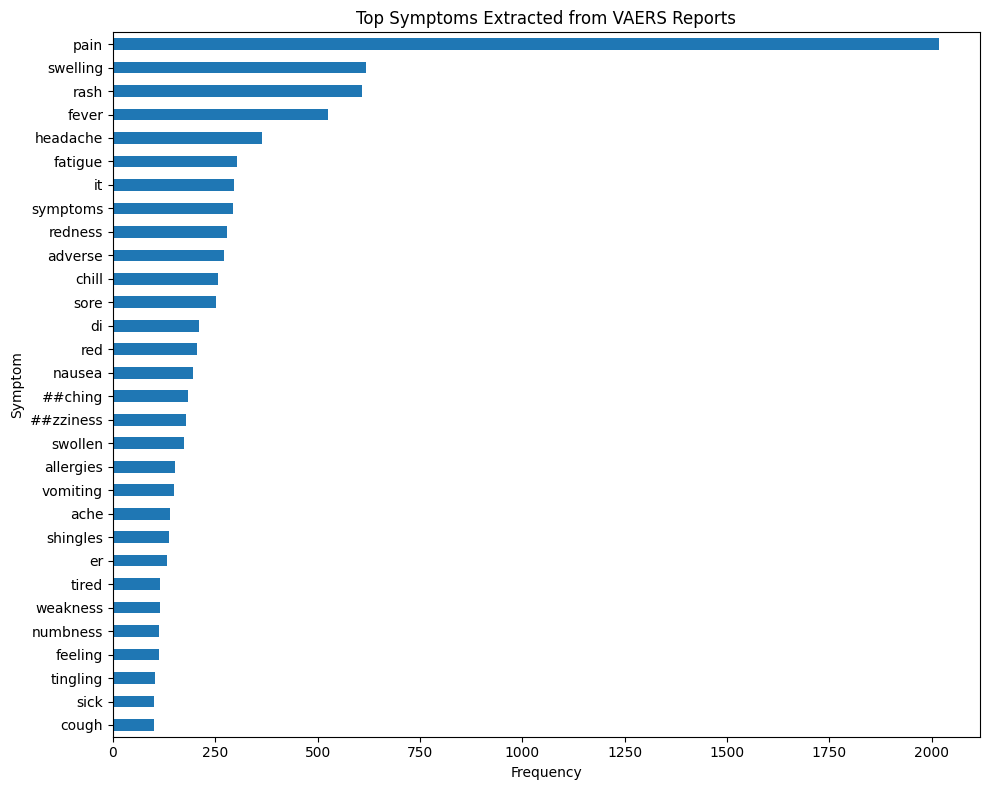

In [ ]:
plt.figure(figsize=(10, 8))

top_symptoms.sort_values().plot(
    kind="barh"
)

plt.title(
    "Top Symptoms Extracted from VAERS Reports"
)

plt.xlabel("Frequency")
plt.ylabel("Symptom")

plt.tight_layout()

plt.show()

In [ ]:
ner_results_path = (
    f"{PROJECT_DIR}/results/"
    "vaers_ner_entities.csv"
)

entity_df.to_csv(
    ner_results_path,
    index=False
)

print("NER results saved to:")
print(ner_results_path)

NER results saved to:
/content/ADEGuard-GenAI/results/vaers_ner_entities.csv


In [ ]:
ner_results_path = (
    f"{PROJECT_DIR}/results/"
    "vaers_ner_entities.csv"
)

entity_df.to_csv(
    ner_results_path,
    index=False
)

print("NER results saved to:")
print(ner_results_path)

NER results saved to:
/content/ADEGuard-GenAI/results/vaers_ner_entities.csv


In [ ]:
from sentence_transformers import SentenceTransformer

EMBEDDING_MODEL_NAME = "all-MiniLM-L6-v2"

embedding_model = SentenceTransformer(
    EMBEDDING_MODEL_NAME
)

print("Sentence-BERT model loaded successfully!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Sentence-BERT model loaded successfully!


In [ ]:
symptom_list = (
    symptom_entities["entity_text"]
    .dropna()
    .astype(str)
    .str.lower()
    .str.strip()
)

symptom_list = (
    symptom_list[
        symptom_list.str.len() > 2
    ]
    .drop_duplicates()
    .tolist()
)

print("Unique symptoms:", len(symptom_list))

print("\nFirst 50 symptoms:")
print(symptom_list[:50])

Unique symptoms: 2846

First 50 symptoms:
['flare', '##listers', 'seizure', 'eye deviation', 'rolling', 'shaking', 'seizures', 'lip smacking', 'jerking', '##uising', 'pain', 'swelling', 'swollen', 'nauseated', 'hurting', 'knot', 'itch', '##bromyalgia', '##omax', 'inflammation', 'flu', 'influenza - like symptoms', 'influenza', 'like symptoms', 'rash', 'adverse events', 'temperature excursion', 'temperature', '##mpt', '##omatic events', 'adverse', 'dil', '##uent', 'hives', 'tingling sensation', 'tight', 'shortness of breath', 'breathing', 'muscle weakness', 'flared', 'weakness', '##tre', 'under', '##e', 'gain weight', 'problems', 'nerve sensation', 'bruise', 'numb', 'cold']


In [ ]:
symptom_frequency = (
    symptom_entities["entity_text"]
    .dropna()
    .astype(str)
    .str.lower()
    .str.strip()
    .value_counts()
)

MAX_SYMPTOMS = min(
    2000,
    len(symptom_frequency)
)

symptom_vocabulary = (
    symptom_frequency
    .head(MAX_SYMPTOMS)
    .index
    .tolist()
)

print(
    "Symptoms selected for clustering:",
    len(symptom_vocabulary)
)

Symptoms selected for clustering: 2000


In [ ]:
symptom_embeddings = embedding_model.encode(
    symptom_vocabulary,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(
    "Embedding shape:",
    symptom_embeddings.shape
)

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Embedding shape: (2000, 384)


In [ ]:
import umap.umap_ as umap

umap_model = umap.UMAP(
    n_components=2,
    random_state=42,
    n_neighbors=15,
    min_dist=0.1
)

symptom_2d = umap_model.fit_transform(
    symptom_embeddings
)

print(
    "UMAP output shape:",
    symptom_2d.shape
)

UMAP output shape: (2000, 2)


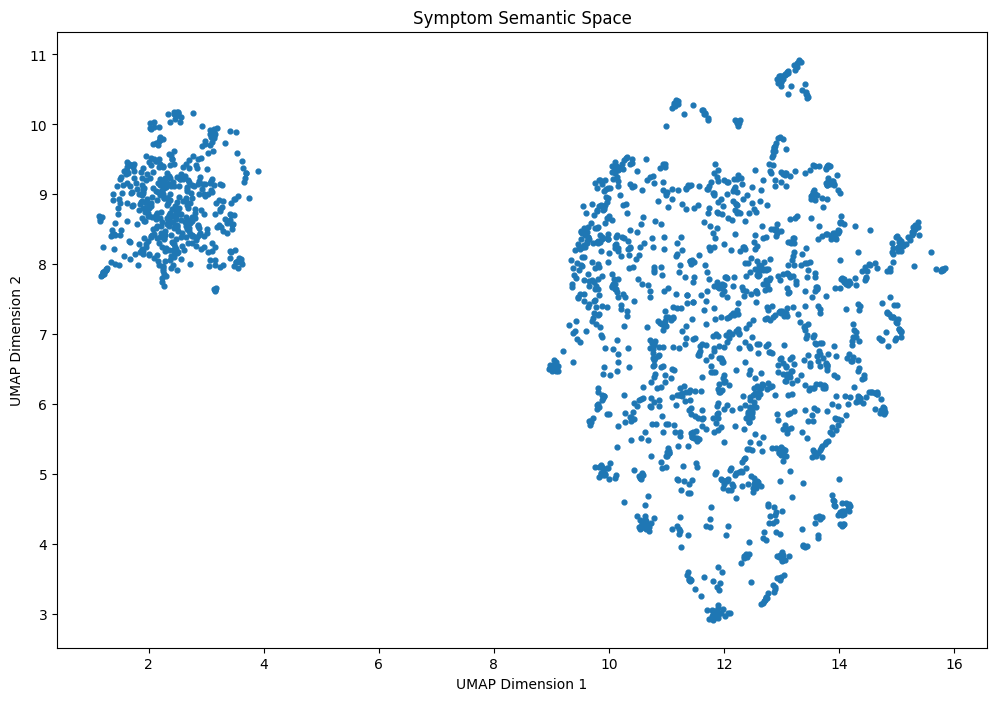

In [ ]:
plt.figure(figsize=(12, 8))

plt.scatter(
    symptom_2d[:, 0],
    symptom_2d[:, 1],
    s=12
)

plt.title(
    "Symptom Semantic Space"
)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")

plt.show()

In [ ]:
import hdbscan

cluster_model = hdbscan.HDBSCAN(
    min_cluster_size=8,
    min_samples=3,
    metric="euclidean"
)

cluster_labels = cluster_model.fit_predict(
    symptom_embeddings
)

print("Clustering completed!")

print(
    "Number of clusters:",
    len(
        set(cluster_labels)
        - {-1}
    )
)

print(
    "Unclustered symptoms:",
    sum(
        cluster_labels == -1
    )
)

Clustering completed!
Number of clusters: 24
Unclustered symptoms: 1180


In [ ]:
symptom_clusters = pd.DataFrame({
    "symptom": symptom_vocabulary,
    "frequency": [
        symptom_frequency[s]
        for s in symptom_vocabulary
    ],
    "cluster": cluster_labels
})

symptom_clusters.head(20)

,symptom,frequency,cluster
0,pain,2017,18
1,swelling,617,9
2,rash,609,12
3,fever,526,-1
4,headache,364,18
5,fatigue,303,8
6,it,296,-1
7,symptoms,294,23
8,redness,278,12
9,adverse,271,23


In [ ]:
cluster_counts = (
    symptom_clusters[
        symptom_clusters["cluster"] != -1
    ]["cluster"]
    .value_counts()
    .sort_index()
)

print(cluster_counts)

cluster
0       8
1       8
2      21
3       8
4      13
5      18
6      12
7     430
8      28
9       9
10     18
11     13
12     31
13     19
14     14
15     29
16      8
17     10
18     44
19     17
20     17
21     11
22     13
23     21
Name: count, dtype: int64


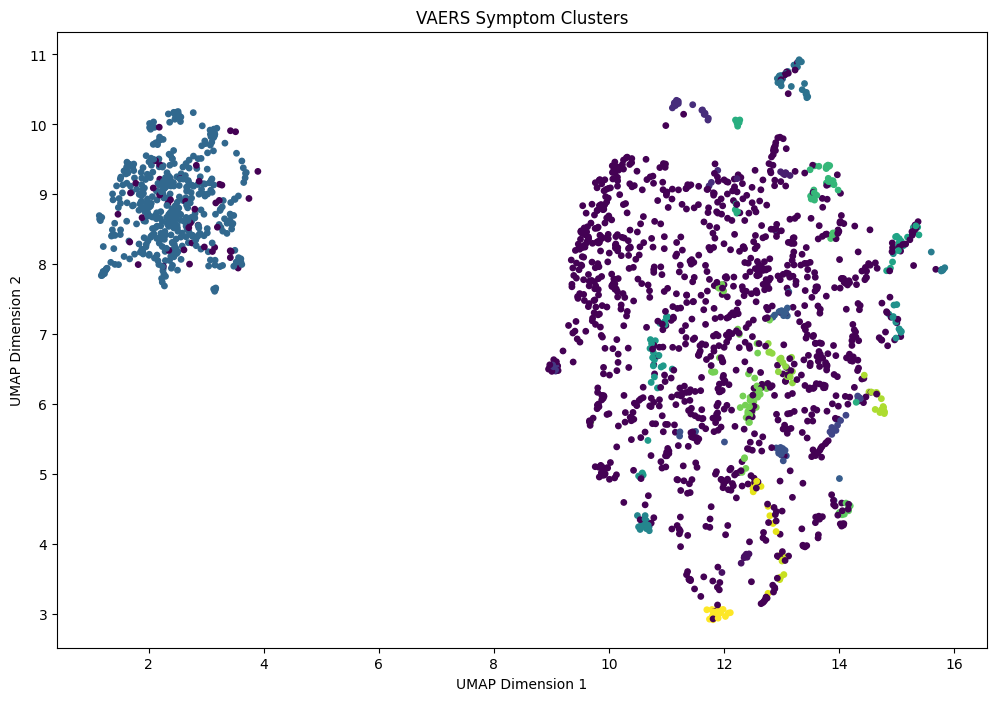

In [ ]:
plt.figure(figsize=(12, 8))

plt.scatter(
    symptom_2d[:, 0],
    symptom_2d[:, 1],
    c=cluster_labels,
    s=15
)

plt.title(
    "VAERS Symptom Clusters"
)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")

plt.show()

In [ ]:
def show_cluster(cluster_id, n=20):

    cluster_data = symptom_clusters[
        symptom_clusters["cluster"] == cluster_id
    ].sort_values(
        "frequency",
        ascending=False
    )

    return cluster_data.head(n)

In [ ]:
available_clusters = sorted(
    set(cluster_labels) - {-1}
)

print(
    "Available clusters:",
    available_clusters
)

Available clusters: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]


In [ ]:
if available_clusters:

    show_cluster(
        available_clusters[0],
        20
    )

In [ ]:
for cluster_id in available_clusters[:10]:

    print("\n" + "=" * 60)
    print("CLUSTER:", cluster_id)

    print(
        show_cluster(
            cluster_id,
            15
        )["symptom"].tolist()
    )


CLUSTER: 0
['inflammation', 'immune', 'immune response', 'inflammatory reaction', 'immune th', 'immune throm', 'immun', 'immune system']

CLUSTER: 1
['fell', 'fall', 'falls', 'falling', 'low', 'falling down', 'down', 'mechanical fall']

CLUSTER: 2
['faint', 'syncope', 'fainted', 'fainting', 'passed out', 'sync', 'passed', 'syncopal episode', 'pass', 'faints', 'syncope episode', 'near syncope', 'syncopa', 'fainting episode', 'near syncope episode']

CLUSTER: 3
['heart', 'atrial flutter', 'heart flutter', 'heart pounding', 'cardiac flutter', 'fluttery feeling', 'racing heart', 'racing heartbeat']

CLUSTER: 4
['bad', 'sense of smell', 'taste', 'smell', 'awful', 'awful taste', 'loss of taste', 'of smell', 'terrible', 'badly', 'loss of smell', 'horrible', 'lost sense of taste']

CLUSTER: 5
['shortness of breath', 'breathing', 'difficulty breathing', 'trouble breathing', 'shortness', 'respiratory', 'bloody nose', 'labored breathing', 'nasal', 'rhinorr', 'short of breath', 'rhino', 'gasping'

In [ ]:
symptom_cluster_map = dict(
    zip(
        symptom_clusters["symptom"],
        symptom_clusters["cluster"]
    )
)

symptom_entities["normalized_symptom"] = (
    symptom_entities["entity_text"]
    .astype(str)
    .str.lower()
    .str.strip()
)

symptom_entities["cluster"] = (
    symptom_entities["normalized_symptom"]
    .map(symptom_cluster_map)
)

symptom_entities.head()

,VAERS_ID,severity,entity_text,entity_label,confidence,normalized_symptom,cluster
0,2789893,mild,flare,SYMPTOM,0.7982,flare,-1.0
5,2789893,mild,b,SYMPTOM,0.9999,b,-1.0
6,2789893,mild,##listers,SYMPTOM,0.7268,##listers,7.0
14,2748993,severe,seizure,SYMPTOM,0.9999,seizure,-1.0
15,2748993,severe,dr,SYMPTOM,0.5281,dr,-1.0


In [ ]:
symptom_with_severity = symptom_entities.copy()

print(symptom_with_severity.shape)
symptom_with_severity.head()

(20539, 7)


,VAERS_ID,severity,entity_text,entity_label,confidence,normalized_symptom,cluster
0,2789893,mild,flare,SYMPTOM,0.7982,flare,-1.0
5,2789893,mild,b,SYMPTOM,0.9999,b,-1.0
6,2789893,mild,##listers,SYMPTOM,0.7268,##listers,7.0
14,2748993,severe,seizure,SYMPTOM,0.9999,seizure,-1.0
15,2748993,severe,dr,SYMPTOM,0.5281,dr,-1.0


In [ ]:
cluster_severity = pd.crosstab(
    symptom_with_severity["cluster"],
    symptom_with_severity["severity"]
)

cluster_severity

severity,mild,moderate,severe
cluster,,,
-1.0,5875,619,1034
0.0,46,12,7
1.0,36,6,14
2.0,177,42,18
3.0,18,1,2
4.0,31,2,1
5.0,78,33,35
6.0,326,32,34
7.0,1932,178,288


In [ ]:
cluster_severity_stats = (
    symptom_with_severity
    .groupby("cluster")
    .agg(
        total_mentions=("severity", "size"),
        severe_mentions=(
            "severity",
            lambda x: (x == "severe").sum()
        )
    )
)

cluster_severity_stats["severe_percentage"] = (
    cluster_severity_stats["severe_mentions"]
    /
    cluster_severity_stats["total_mentions"]
    * 100
)

cluster_severity_stats = (
    cluster_severity_stats
    .sort_values(
        "severe_percentage",
        ascending=False
    )
)

cluster_severity_stats.head(20)

,total_mentions,severe_mentions,severe_percentage
cluster,,,
11.0,58,21,36.206897
1.0,56,14,25.000000
5.0,146,35,23.972603
15.0,95,22,23.157895
13.0,126,26,20.634921
16.0,47,8,17.021277
19.0,257,38,14.785992
-1.0,7528,1034,13.735388
8.0,583,77,13.207547


In [ ]:
symptom_intelligence = symptom_clusters.merge(
    cluster_severity_stats,
    left_on="cluster",
    right_index=True,
    how="left"
)

symptom_intelligence = (
    symptom_intelligence
    .sort_values(
        "frequency",
        ascending=False
    )
)

symptom_intelligence.head(30)

,symptom,frequency,cluster,total_mentions,severe_mentions,severe_percentage
0,pain,2017,18,3170,239,7.539432
1,swelling,617,9,821,23,2.801462
2,rash,609,12,1330,35,2.631579
3,fever,526,-1,7528,1034,13.735388
4,headache,364,18,3170,239,7.539432
5,fatigue,303,8,583,77,13.207547
6,it,296,-1,7528,1034,13.735388
7,symptoms,294,23,947,41,4.329461
8,redness,278,12,1330,35,2.631579
9,adverse,271,23,947,41,4.329461


In [ ]:
symptom_results_path = (
    f"{PROJECT_DIR}/results/"
    "symptom_intelligence.csv"
)

symptom_intelligence.to_csv(
    symptom_results_path,
    index=False
)

print(
    "Symptom intelligence saved:"
)

print(symptom_results_path)

Symptom intelligence saved:
/content/ADEGuard-GenAI/results/symptom_intelligence.csv


In [ ]:
embedding_path = (
    f"{PROJECT_DIR}/models/embeddings/"
    "symptom_embeddings.npy"
)

np.save(
    embedding_path,
    symptom_embeddings
)

print(
    "Embeddings saved:"
)

print(embedding_path)

Embeddings saved:
/content/ADEGuard-GenAI/models/embeddings/symptom_embeddings.npy


In [ ]:
import shap
from lime.lime_text import LimeTextExplainer

print("SHAP version:", shap.__version__)
print("LIME loaded successfully")

SHAP version: 0.52.0
LIME loaded successfully


In [ ]:
def predict_proba(texts):
    model.eval()

    inputs = tokenizer(
        list(texts),
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        outputs = model(**inputs)
        probabilities = torch.softmax(outputs.logits, dim=-1)

    return probabilities.cpu().numpy()

test_text = [
    "Patient developed severe headache and was admitted to hospital."
]

probs = predict_proba(test_text)

print("Probabilities:")
for label, probability in zip(label_encoder.classes_, probs[0]):
    print(f"{label}: {probability:.4f}")

Probabilities:
mild: 0.0184
moderate: 0.0080
severe: 0.9737


In [ ]:
lime_explainer = LimeTextExplainer(
    class_names=list(label_encoder.classes_),
    random_state=42
)

print("LIME explainer created.")

LIME explainer created.


In [ ]:
sample_row = ml_data.sample(
    1,
    random_state=42
).iloc[0]

sample_text = sample_row["medical_text"]
actual_severity = sample_row["severity"]

print("Actual severity:", actual_severity)
print("\nMedical text:")
print(sample_text[:2000])

Actual severity: mild

Medical text:
Flareup of Bullous Pemphigoid starting one week after vaccination. Multiple blisters on arms, legs, torso, and hands. CHF, Bullous Pemphigoid Xarelto? Allopurinal, Entresto


In [ ]:
lime_explanation = lime_explainer.explain_instance(
    sample_text,
    predict_proba,
    num_features=15,
    num_samples=200
)

print("LIME explanation:\n")

for word, weight in lime_explanation.as_list():
    print(f"{word:30s} {weight:+.4f}")

LIME explanation:

blisters                       +0.0795
Flareup                        +0.0487
Pemphigoid                     -0.0380
starting                       +0.0377
Allopurinal                    +0.0363
vaccination                    +0.0352
CHF                            +0.0322
torso                          +0.0284
hands                          +0.0247
on                             -0.0229
of                             +0.0200
Multiple                       +0.0160
arms                           -0.0149
Xarelto                        -0.0122
week                           +0.0114


In [ ]:
sample_probabilities = predict_proba([sample_text])[0]

predicted_id = np.argmax(sample_probabilities)
predicted_class = label_encoder.classes_[predicted_id]

print("Predicted class:", predicted_class)
print("Confidence:", round(float(sample_probabilities[predicted_id]), 4))

lime_explanation = lime_explainer.explain_instance(
    sample_text,
    predict_proba,
    labels=[predicted_id],
    num_features=15,
    num_samples=200
)

print("\nImportant features for predicted class:\n")

for word, weight in lime_explanation.as_list(label=predicted_id):
    print(f"{word:30s} {weight:+.4f}")

Predicted class: severe
Confidence: 0.3547

Important features for predicted class:

CHF                            +0.3208
Bullous                        +0.2244
blisters                       -0.2136
legs                           +0.2054
Allopurinal                    -0.1845
Flareup                        -0.1758
Pemphigoid                     +0.1725
of                             -0.1333
Multiple                       +0.1085
after                          +0.0954
on                             +0.0726
one                            +0.0618
hands                          -0.0443
starting                       -0.0433
and                            +0.0391


In [ ]:
lime_records = []

for word, weight in lime_explanation.as_list(label=predicted_id):
    lime_records.append({
        "feature": word,
        "weight": weight,
        "predicted_class": predicted_class
    })

lime_df = pd.DataFrame(lime_records)

lime_path = f"{PROJECT_DIR}/results/lime_explanation.csv"
lime_df.to_csv(lime_path, index=False)

print("LIME explanation saved to:")
print(lime_path)

display(lime_df)

LIME explanation saved to:
/content/ADEGuard-GenAI/results/lime_explanation.csv


,feature,weight,predicted_class
0,CHF,0.320831,severe
1,Bullous,0.224365,severe
2,blisters,-0.213636,severe
3,legs,0.205411,severe
4,Allopurinal,-0.184539,severe
5,Flareup,-0.175842,severe
6,Pemphigoid,0.172545,severe
7,of,-0.133256,severe
8,Multiple,0.108468,severe
9,after,0.095430,severe


In [ ]:
shap_masker = shap.maskers.Text(tokenizer)

print("SHAP text masker created.")

SHAP text masker created.


In [ ]:
shap_explainer = shap.Explainer(
    predict_proba,
    shap_masker,
    output_names=list(label_encoder.classes_),
    algorithm="partition"
)

print("SHAP explainer created.")

SHAP explainer created.


In [ ]:
shap_text = sample_text[:1000]

print("Text being explained:\n")
print(shap_text)

Text being explained:

Flareup of Bullous Pemphigoid starting one week after vaccination. Multiple blisters on arms, legs, torso, and hands. CHF, Bullous Pemphigoid Xarelto? Allopurinal, Entresto


In [ ]:
shap_values = shap_explainer(
    [shap_text],
    max_evals=200
)

print("SHAP explanation generated.")

SHAP explanation generated.


In [ ]:
shap.plots.text(shap_values[0])

In [ ]:
predicted_id = np.argmax(
    predict_proba([shap_text])[0]
)

predicted_class = label_encoder.classes_[predicted_id]

print("Predicted severity:", predicted_class)

print("\nSHAP values shape:")
print(shap_values.values.shape)

Predicted severity: severe

SHAP values shape:
(1, 59, 3)


In [ ]:
shap_data = shap_values[0]

print("Available SHAP outputs:")
print(shap_data.output_names)

Available SHAP outputs:
[np.str_('mild'), np.str_('moderate'), np.str_('severe')]


In [ ]:
shap_values_array = np.array(shap_data.values)

print("SHAP array shape:", shap_values_array.shape)

SHAP array shape: (59, 3)


In [ ]:
tokens = list(shap_data.data)

shap_records = []

for i, token in enumerate(tokens):
    record = {
        "token": token
    }

    for class_index, class_name in enumerate(label_encoder.classes_):
        try:
            record[f"shap_{class_name}"] = float(
                shap_values_array[i, class_index]
            )
        except:
            pass

    shap_records.append(record)

shap_df = pd.DataFrame(shap_records)

shap_path = f"{PROJECT_DIR}/results/shap_explanation.csv"
shap_df.to_csv(shap_path, index=False)

print("SHAP explanation saved:")
print(shap_path)

display(shap_df.head(20))

SHAP explanation saved:
/content/ADEGuard-GenAI/results/shap_explanation.csv


,token,shap_mild,shap_moderate,shap_severe
0,,-0.001562,0.000062,0.001500
1,F,-0.027168,0.004002,0.023166
2,lar,-0.027168,0.004002,0.023166
3,eu,-0.029964,0.003521,0.026443
4,p,-0.029964,0.003521,0.026443
5,of,0.005274,0.002437,-0.007711
6,Bull,-0.014421,0.002088,0.012333
7,ous,-0.021603,0.000229,0.021374
8,P,-0.010627,0.008254,0.002373
9,em,-0.010627,0.008254,0.002373


In [ ]:
class_index = predicted_id

if shap_values_array.ndim == 2:
    shap_df["importance"] = np.abs(
        shap_values_array[:, class_index]
    )

    shap_df["direction"] = np.sign(
        shap_values_array[:, class_index]
    )

    top_shap_tokens = (
        shap_df
        .sort_values("importance", ascending=False)
        .head(15)
    )

    display(top_shap_tokens)

,token,shap_mild,shap_moderate,shap_severe,importance,direction
36,CH,-0.098632,0.007588,0.091044,0.091044,1.0
37,F,-0.086486,0.000886,0.085599,0.085599,1.0
22,Multiple,-0.054184,0.000430,0.053754,0.053754,1.0
54,",",0.021339,0.030501,-0.051841,0.051841,-1.0
55,En,0.009890,0.025713,-0.035603,0.035603,-1.0
35,.,0.013732,0.020894,-0.034625,0.034625,-1.0
39,Bull,-0.023072,-0.008200,0.031272,0.031272,1.0
29,legs,-0.033410,0.004612,0.028798,0.028798,1.0
4,p,-0.029964,0.003521,0.026443,0.026443,1.0
3,eu,-0.029964,0.003521,0.026443,0.026443,1.0


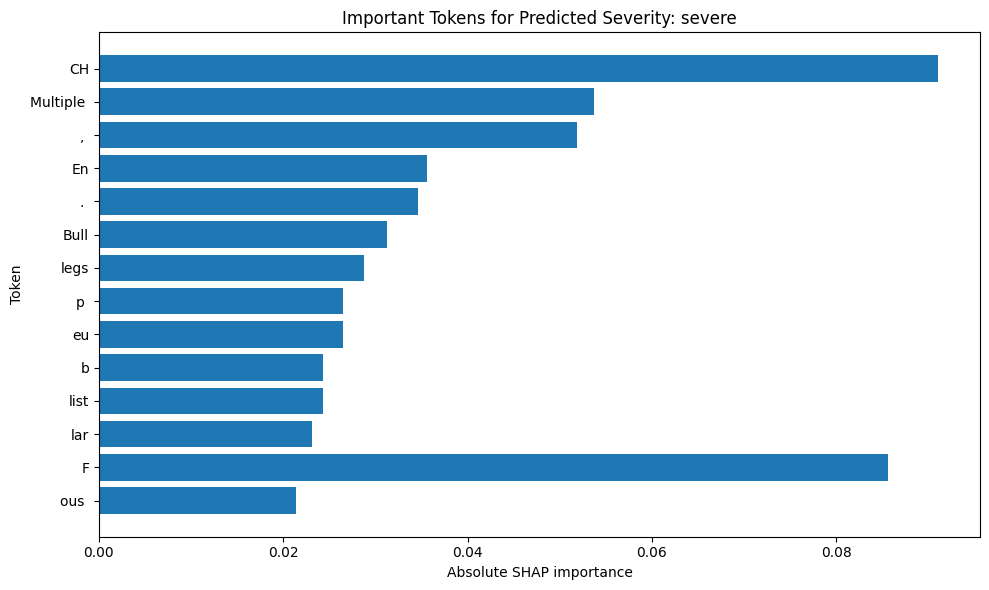

In [ ]:
if "top_shap_tokens" in globals():

    plt.figure(figsize=(10, 6))

    plt.barh(
        top_shap_tokens["token"][::-1],
        top_shap_tokens["importance"][::-1]
    )

    plt.xlabel("Absolute SHAP importance")
    plt.ylabel("Token")
    plt.title(
        f"Important Tokens for Predicted Severity: {predicted_class}"
    )

    plt.tight_layout()
    plt.show()

In [ ]:
print("Actual severity:")
print(actual_severity)

print("\nPredicted severity:")
print(predicted_class)

print("\nModel probabilities:")

for label, probability in zip(
    label_encoder.classes_,
    sample_probabilities
):
    print(
        f"{label:10s}: "
        f"{probability:.4f}"
    )

print("\nTop LIME features:")

for word, weight in lime_explanation.as_list(
    label=predicted_id
)[:10]:
    print(
        f"{word:25s} {weight:+.4f}"
    )


========== XAI SUMMARY ==========

Actual severity:
mild

Predicted severity:
severe

Model probabilities:
mild      : 0.2968
moderate  : 0.3485
severe    : 0.3547

Top LIME features:
CHF                       +0.3208
Bullous                   +0.2244
blisters                  -0.2136
legs                      +0.2054
Allopurinal               -0.1845
Flareup                   -0.1758
Pemphigoid                +0.1725
of                        -0.1333
Multiple                  +0.1085
after                     +0.0954

XAI analysis completed.


In [ ]:
xai_summary = {
    "vaers_id": str(sample_row["VAERS_ID"]),
    "actual_severity": str(actual_severity),
    "predicted_severity": str(predicted_class),
    "confidence": float(sample_probabilities[predicted_id]),
    "lime_features": [
        {
            "feature": str(word),
            "weight": float(weight)
        }
        for word, weight in lime_explanation.as_list(
            label=predicted_id
        )
    ]
}

xai_json_path = f"{PROJECT_DIR}/results/xai_summary.json"

with open(xai_json_path, "w") as f:
    json.dump(xai_summary, f, indent=4)

print("XAI summary saved to:")
print(xai_json_path)

XAI summary saved to:
/content/ADEGuard-GenAI/results/xai_summary.json


In [ ]:
!pip install -q openai

In [ ]:
import os
import json
from openai import OpenAI

print("OpenAI library loaded.")

OpenAI library loaded.


In [ ]:
from google.colab import userdata

GROQ_API_KEY = userdata.get("OPENAI_API_KEY")

if GROQ_API_KEY:
    print("API key loaded successfully.")
else:
    print("API key was not found.")

API key loaded successfully.


In [ ]:
client = OpenAI(
    api_key=GROQ_API_KEY,
    base_url="https://api.groq.com/openai/v1"
)

print("GenAI client ready.")

GenAI client ready.


In [ ]:
def create_genai_prompt(
    medical_text,
    entities,
    predicted_severity,
    confidence,
    symptom_cluster=None
):

    prompt = f"""
You are the GenAI explanation component of ADEGuard,
an AI system for adverse-event analysis using VAERS data.

Analyze the following adverse-event report and the outputs
from our machine-learning pipeline.

IMPORTANT:
- Do not diagnose the patient.
- Do not claim that a vaccine caused the event.
- Do not recommend treatment.
- Do not invent medical facts that are not present.
- Clearly distinguish reported information from AI-generated interpretation.
- Treat the predicted severity as a model prediction, not a clinical diagnosis.

VAERS REPORT:
{medical_text}

DETECTED MEDICAL ENTITIES:
{json.dumps(entities, indent=2)}

MODEL-PREDICTED SEVERITY:
{predicted_severity}

MODEL CONFIDENCE:
{confidence:.2%}

SYMPTOM CLUSTER:
{symptom_cluster}

Generate a concise structured analysis containing:

1. Event Summary
2. Detected Symptoms
3. Detected Drugs/Vaccines
4. Other Important Entities
5. Predicted Severity
6. Key Evidence
7. Symptom Pattern
8. Important Uncertainty
9. Safety/Causality Disclaimer

Return the answer in clear JSON format.
"""

    return prompt

In [ ]:
genai_sample = ner_working_data.sample(
    1,
    random_state=123
).iloc[0]

genai_vaers_id = genai_sample["VAERS_ID"]
genai_text = genai_sample["medical_text"]
genai_severity = genai_sample["severity"]

genai_entities = genai_sample["entities"]

print("VAERS ID:", genai_vaers_id)
print("\nSeverity:", genai_severity)
print("\nReport:")
print(genai_text[:3000])

VAERS ID: 2897378

Severity: mild

Report:
Swollen, red, painful at injection site. Nausea, diarrhea, aches, fatigue


In [ ]:
genai_probabilities = predict_proba(
    [genai_text]
)[0]

predicted_id = np.argmax(
    genai_probabilities
)

genai_predicted_severity = (
    label_encoder.inverse_transform(
        [predicted_id]
    )[0]
)

genai_confidence = float(
    genai_probabilities[predicted_id]
)

print("Predicted severity:", genai_predicted_severity)
print("Confidence:", f"{genai_confidence:.2%}")

print("\nAll probabilities:")

for label, probability in zip(
    label_encoder.classes_,
    genai_probabilities
):
    print(
        f"{label}: {probability:.2%}"
    )

Predicted severity: mild
Confidence: 99.69%

All probabilities:
mild: 99.69%
moderate: 0.29%
severe: 0.02%


In [ ]:
sample_symptom_clusters = []

for entity in genai_entities:

    if entity["label"].upper() == "SYMPTOM":

        symptom = (
            entity["text"]
            .lower()
            .strip()
        )

        cluster = symptom_cluster_map.get(
            symptom,
            -1
        )

        sample_symptom_clusters.append(
            cluster
        )

sample_symptom_clusters = list(
    set(sample_symptom_clusters)
)

print(
    "Detected symptom clusters:",
    sample_symptom_clusters
)

Detected symptom clusters: [8, 18, -1]


In [ ]:
prompt = create_genai_prompt(
    medical_text=genai_text,
    entities=genai_entities,
    predicted_severity=genai_predicted_severity,
    confidence=genai_confidence,
    symptom_cluster=sample_symptom_clusters
)

print(prompt[:5000])


You are the GenAI explanation component of ADEGuard,
an AI system for adverse-event analysis using VAERS data.

Analyze the following adverse-event report and the outputs
from our machine-learning pipeline.

IMPORTANT:
- Do not diagnose the patient.
- Do not claim that a vaccine caused the event.
- Do not recommend treatment.
- Do not invent medical facts that are not present.
- Clearly distinguish reported information from AI-generated interpretation.
- Treat the predicted severity as a model prediction, not a clinical diagnosis.

VAERS REPORT:
Swollen, red, painful at injection site. Nausea, diarrhea, aches, fatigue

DETECTED MEDICAL ENTITIES:
[
  {
    "text": "painful",
    "original_label": "Detailed_description",
    "label": "DETAILED_DESCRIPTION",
    "confidence": 0.9855,
    "start": 14,
    "end": 21
  },
  {
    "text": "diarr",
    "original_label": "Sign_symptom",
    "label": "SYMPTOM",
    "confidence": 0.9402,
    "start": 49,
    "end": 54
  },
  {
    "text": "ache"

In [ ]:
response = client.chat.completions.create(
    model="openai/gpt-oss-20b",
    messages=[
        {
            "role": "system",
            "content": (
                "You are a careful biomedical NLP "
                "assistant for adverse-event analysis."
            )
        },
        {
            "role": "user",
            "content": prompt
        }
    ],
    temperature=0.2
)

genai_output = response.choices[0].message.content

print(genai_output)

```json
{
  "Event Summary": "The report describes local injection‑site reactions (swollen, red, painful) accompanied by systemic symptoms of nausea, diarrhea, aches, and fatigue.",
  "Detected Symptoms": [
    "painful",
    "diarrhea",
    "ache",
    "fatigue"
  ],
  "Detected Drugs/Vaccines": [],
  "Other Important Entities": [
    "swollen",
    "red",
    "injection site"
  ],
  "Predicted Severity": "mild",
  "Key Evidence": [
    {
      "entity": "painful",
      "confidence": 0.9855,
      "text_span": "painful"
    },
    {
      "entity": "diarrhea",
      "confidence": 0.9402,
      "text_span": "diarr"
    },
    {
      "entity": "ache",
      "confidence": 0.9999,
      "text_span": "ache"
    },
    {
      "entity": "fatigue",
      "confidence": 0.9999,
      "text_span": "fatigue"
    }
  ],
  "Symptom Pattern": "[8, 18, -1]",
  "Important Uncertainty": [
    "The pipeline did not detect all reported symptoms (e.g., swollen, red, nausea).",
    "The severity predict

In [ ]:
def clean_json_output(text):
    text = text.strip()
    if text.startswith("```"):
        text = text.split("```")[1]
        if text.startswith("json"):
            text = text[4:]
    return text.strip()

In [ ]:
try:
    genai_json = json.loads(clean_json_output(genai_output))

    print(
        json.dumps(
            genai_json,
            indent=2
        )
    )

except Exception as e:

    print("Could not parse JSON automatically.")
    print("Raw output:")
    print(genai_output)

    genai_json = {
        "raw_output": genai_output
    }

{
  "Event Summary": "The report describes local injection\u2011site reactions (swollen, red, painful) accompanied by systemic symptoms of nausea, diarrhea, aches, and fatigue.",
  "Detected Symptoms": [
    "painful",
    "diarrhea",
    "ache",
    "fatigue"
  ],
  "Detected Drugs/Vaccines": [],
  "Other Important Entities": [
    "swollen",
    "red",
    "injection site"
  ],
  "Predicted Severity": "mild",
  "Key Evidence": [
    {
      "entity": "painful",
      "confidence": 0.9855,
      "text_span": "painful"
    },
    {
      "entity": "diarrhea",
      "confidence": 0.9402,
      "text_span": "diarr"
    },
    {
      "entity": "ache",
      "confidence": 0.9999,
      "text_span": "ache"
    },
    {
      "entity": "fatigue",
      "confidence": 0.9999,
      "text_span": "fatigue"
    }
  ],
  "Symptom Pattern": "[8, 18, -1]",
  "Important Uncertainty": [
    "The pipeline did not detect all reported symptoms (e.g., swollen, red, nausea).",
    "The severity prediction

In [ ]:
print('ADEGuard GENAI INSIGHT')

if isinstance(genai_json, dict):

    for key, value in genai_json.items():

        print(f"\n{key.upper()}")
        print(value)

                 ADEGuard GENAI INSIGHT

EVENT SUMMARY
--------------------------------------------------
The report describes local injection‑site reactions (swollen, red, painful) accompanied by systemic symptoms of nausea, diarrhea, aches, and fatigue.

DETECTED SYMPTOMS
--------------------------------------------------
['painful', 'diarrhea', 'ache', 'fatigue']

DETECTED DRUGS/VACCINES
--------------------------------------------------
[]

OTHER IMPORTANT ENTITIES
--------------------------------------------------
['swollen', 'red', 'injection site']

PREDICTED SEVERITY
--------------------------------------------------
mild

KEY EVIDENCE
--------------------------------------------------
[{'entity': 'painful', 'confidence': 0.9855, 'text_span': 'painful'}, {'entity': 'diarrhea', 'confidence': 0.9402, 'text_span': 'diarr'}, {'entity': 'ache', 'confidence': 0.9999, 'text_span': 'ache'}, {'entity': 'fatigue', 'confidence': 0.9999, 'text_span': 'fatigue'}]

SYMPTOM PATTERN
----------

In [ ]:
genai_result = {
    "VAERS_ID": str(genai_vaers_id),
    "medical_text": genai_text,
    "predicted_severity": genai_predicted_severity,
    "confidence": genai_confidence,
    "entities": genai_entities,
    "symptom_clusters": sample_symptom_clusters,
    "genai_analysis": genai_json
}

genai_result_path = (
    f"{PROJECT_DIR}/results/"
    "genai_insight_sample.json"
)

with open(
    genai_result_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        genai_result,
        f,
        indent=4,
        ensure_ascii=False
    )

print("GenAI result saved to:")
print(genai_result_path)

GenAI result saved to:
/content/ADEGuard-GenAI/results/genai_insight_sample.json


In [ ]:
def adeguard_analyze(text):

    probabilities = predict_proba([text])[0]

    predicted_id = np.argmax(probabilities)

    predicted_severity = (
        label_encoder.inverse_transform(
            [predicted_id]
        )[0]
    )

    confidence = float(
        probabilities[predicted_id]
    )

    entities = extract_normalized_entities(text)
    symptoms = []

    for entity in entities:

        if entity["label"].upper() == "SYMPTOM":

            symptoms.append(
                entity["text"]
            )

    clusters = []

    for symptom in symptoms:

        normalized = (
            symptom.lower()
            .strip()
        )

        cluster = symptom_cluster_map.get(
            normalized,
            -1
        )

        if cluster != -1:
            clusters.append(cluster)

    clusters = list(set(clusters))

    prompt = create_genai_prompt(
        medical_text=text,
        entities=entities,
        predicted_severity=predicted_severity,
        confidence=confidence,
        symptom_cluster=clusters
    )

    response = client.chat.completions.create(
        model="openai/gpt-oss-20b",
        messages=[
            {
                "role": "system",
                "content": (
                    "You are a careful biomedical NLP "
                    "assistant for adverse-event analysis."
                )
            },
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0.2
    )

    genai_result = (
        response
        .choices[0]
        .message
        .content
    )

    return {
        "severity": predicted_severity,
        "confidence": confidence,
        "probabilities": {
            label: float(probability)
            for label, probability in zip(
                label_encoder.classes_,
                probabilities
            )
        },
        "entities": entities,
        "symptoms": symptoms,
        "symptom_clusters": clusters,
        "genai_analysis": genai_result
    }

In [ ]:
test_patient_report = """
After receiving the vaccine, the patient developed
severe headache, dizziness and vomiting.
The patient was subsequently taken to the emergency
department for evaluation.
"""

result = adeguard_analyze(
    test_patient_report
)

print(
    json.dumps(
        result,
        indent=2,
        ensure_ascii=False
    )
)

{
  "severity": "moderate",
  "confidence": 0.9671616554260254,
  "probabilities": {
    "mild": 0.026167087256908417,
    "moderate": 0.9671616554260254,
    "severe": 0.0066712223924696445
  },
  "entities": [
    {
      "text": "severe",
      "original_label": "Severity",
      "label": "SEVERITY",
      "confidence": 0.9997,
      "start": 52,
      "end": 58
    },
    {
      "text": "headache",
      "original_label": "Sign_symptom",
      "label": "SYMPTOM",
      "confidence": 0.6151,
      "start": 59,
      "end": 67
    },
    {
      "text": "di",
      "original_label": "Sign_symptom",
      "label": "SYMPTOM",
      "confidence": 0.9999,
      "start": 69,
      "end": 71
    },
    {
      "text": "##zziness",
      "original_label": "Sign_symptom",
      "label": "SYMPTOM",
      "confidence": 0.9993,
      "start": 71,
      "end": 78
    },
    {
      "text": "vomiting",
      "original_label": "Sign_symptom",
      "label": "SYMPTOM",
      "confidence": 0.9186,


In [ ]:
print("ADE Guard")

print(
    "\nPredicted Severity:",
    result["severity"].upper()
)

print(
    "Model Confidence:",
    f'{result["confidence"]:.2%}'
)

print("\nDetected Symptoms:")

if result["symptoms"]:
    for symptom in result["symptoms"]:
        print(" •", symptom)
else:
    print(" • No symptoms detected")

print("\nSymptom Clusters:")

if result["symptom_clusters"]:
    for cluster in result["symptom_clusters"]:
        print(" • Cluster", cluster)
else:
    print(" • No cluster identified")

print("\nDetected Medical Entities:")

for entity in result["entities"]:
    print(
        f' • {entity["label"]}: '
        f'{entity["text"]} '
        f'({entity["confidence"]:.2%})'
    )


print(result["genai_analysis"])

                    ADEGuard

Predicted Severity: MODERATE
Model Confidence: 96.72%

Detected Symptoms:
 • headache
 • di
 • ##zziness
 • vomiting

Symptom Clusters:
 • Cluster 18
 • Cluster 22
 • Cluster 7

Detected Medical Entities:
 • SEVERITY: severe (99.97%)
 • SYMPTOM: headache (61.51%)
 • SYMPTOM: di (99.99%)
 • SYMPTOM: ##zziness (99.93%)
 • SYMPTOM: vomiting (91.86%)
 • CLINICAL_EVENT: taken (99.98%)
 • NONBIOLOGICAL_LOCATION: emergency department (99.82%)

                    GenAI Insight
```json
{
  "Event Summary": "The patient reported experiencing a severe headache, dizziness, and vomiting after receiving a vaccine and was subsequently taken to the emergency department for evaluation.",
  "Detected Symptoms": [
    {
      "symptom": "headache",
      "severity": "severe",
      "confidence": 0.6151
    },
    {
      "symptom": "dizziness",
      "severity": "severe",
      "confidence": 0.9993
    },
    {
      "symptom": "vomiting",
      "severity": "severe",
      

In [ ]:
!pip install -q streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 74.7 MB/s eta 0:00:00


In [ ]:
import os

print("Project directory:")
print(PROJECT_DIR)

print("\nContents:")

for root, dirs, files in os.walk(PROJECT_DIR):
    level = root.replace(PROJECT_DIR, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:10]:
        print(f"{indent}  {file}")

Project directory:
/content/ADEGuard-GenAI

Contents:
ADEGuard-GenAI/
  data/
    processed/
      vaers_2024_2026_processed.csv
    raw/
      2025VAERSSYMPTOMS.csv
      2025VAERSVAX.csv
      2024VAERSDATA.csv
      2026VAERSVAX.csv
      2025VAERSDATA.csv
      2024VAERSSYMPTOMS.csv
      2026VAERSSYMPTOMS.csv
      2026VAERSDATA.csv
      2024VAERSVAX.csv
    combined/
      vaers_2024_2026_symptoms.csv
      vaers_2024_2026_vaccines.csv
      vaers_2024_2026_main.csv
  reports/
  models/
    severity/
      checkpoint-21318/
        scheduler.pt
        trainer_state.json
        scaler.pt
        model.safetensors
        optimizer.pt
        config.json
        rng_state.pth
        training_args.bin
        tokenizer.json
        tokenizer_config.json
      checkpoint-10659/
        scheduler.pt
        trainer_state.json
        scaler.pt
        model.safetensors
        optimizer.pt
        config.json
        rng_state.pth
        training_args.bin
        tokenizer.json
 

In [ ]:
from huggingface_hub import login
login()

In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

severity_model_path = f"{PROJECT_DIR}/models/severity/biobert"

model_to_push = AutoModelForSequenceClassification.from_pretrained(severity_model_path)
tokenizer_to_push = AutoTokenizer.from_pretrained(severity_model_path)

model_to_push.push_to_hub("kashishs25/adeguard-severity-biobert")
tokenizer_to_push.push_to_hub("kashishs25/adeguard-severity-biobert")

print("Model uploaded successfully!")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...gbnmmok/model.safetensors:   0%|          |  564kB /  433MB            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Model uploaded successfully!
